# Notebook 07 — Explainability (SHAP)

## Objective
Explain WHY the AHRF model makes the SOH predictions it does, using SHAP (SHapley Additive exPlanations) -- both globally (which features matter most overall) and locally (why one specific prediction came out the way it did).

## Why This Step Is Needed
A model that only reports accuracy numbers is a black box. SHAP gives a mathematically grounded (not just visual/hand-wavy) explanation, which is important both for real battery-safety trust and for defending the project in a viva.

## Workflow Position
```
01 Data Understanding -> 02 Preprocessing -> 03 Feature Engineering -> 04 Ground Truth Labels
-> 05 Model Training (AHRF) -> 06 Model Comparison -> [YOU ARE HERE] 07 Explainability (SHAP)
-> 08 Decision Engine & Summary
```


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from src.core.config import FEATURE_DATA, MODELS, FIGURES
from src.explainability.shap_utils import (
    get_shap_values, plot_shap_summary, plot_shap_bar, plot_shap_dependence,
)

plt.rcParams["figure.figsize"] = (10, 6)


## 2. Load the Trained AHRF Model and Test Data

We reload the SOH AHRF model saved in Notebook 05, so this notebook can be re-run independently without retraining.


In [3]:
ahrf_soh = joblib.load(MODELS / "soh_ahrf.pkl")
feature_columns = joblib.load(MODELS / "soh_feature_columns.pkl")

df = pd.read_csv(FEATURE_DATA / "full_labeled_dataset.csv").sort_values("cycle_index").reset_index(drop=True)

n = len(df)
split = int(n * 0.8)
X_test = df.iloc[split:][feature_columns]
y_test = df.iloc[split:]["SOH (%)"]

print("Test set shape:", X_test.shape)


Test set shape: (34, 67)


## 3. Compute SHAP Values

**Important note:** `AdaptiveWeightedRF` is a wrapper around a `RandomForestRegressor`, not a tree model itself. SHAP's `TreeExplainer` needs the underlying forest, so we pass `ahrf_soh.forest_`, not `ahrf_soh` directly. This means the SHAP explanation reflects the forest's structure and feature importances; the per-tree weighting on top of it (AHRF's own contribution) shifts which trees' opinions count more, but doesn't change what each tree individually learned.


In [4]:
explainer, shap_values = get_shap_values(ahrf_soh.forest_, X_test)
print("SHAP values shape:", shap_values.shape, "(rows = test samples, columns = features)")


SHAP values shape: (34, 67) (rows = test samples, columns = features)


## 4. Global Feature Importance — SHAP Bar Chart

The simplest, most viva-friendly figure: which features matter most, on average, across all predictions.


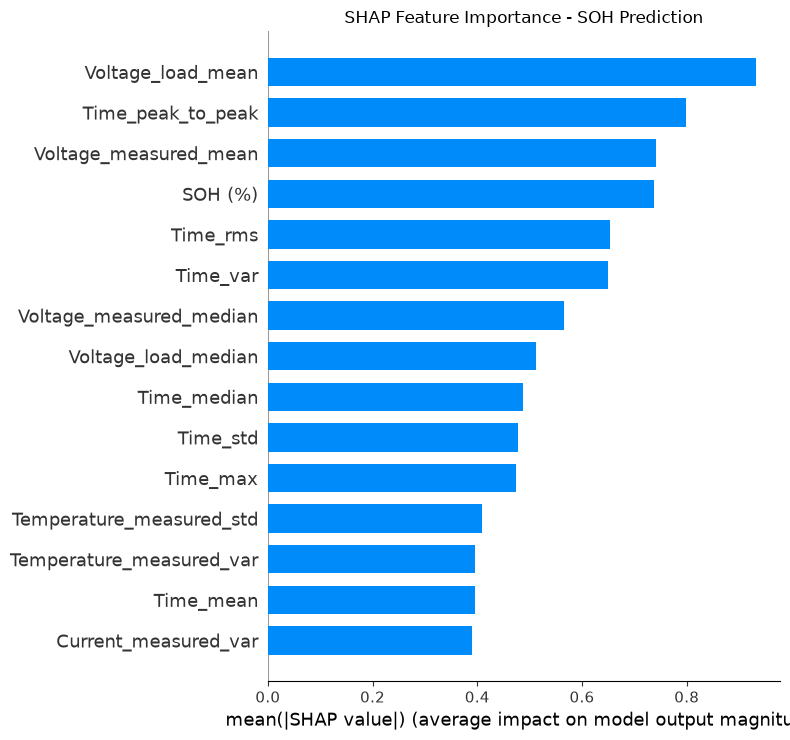

In [5]:
plot_shap_bar(shap_values, X_test, max_display=15, title="SHAP Feature Importance - SOH Prediction")


### Observation
Features derived from voltage and discharge duration (e.g. `Voltage_measured_mean`, `Time_max`) are expected to rank highly, since these directly reflect the physical degradation mechanisms (capacity fade, internal resistance growth) discussed in the project's feature engineering notes.


## 5. SHAP Summary Plot (Beeswarm)

A richer version of the bar chart: shows not just which features matter, but HOW (whether a high value of that feature pushes the prediction up or down).


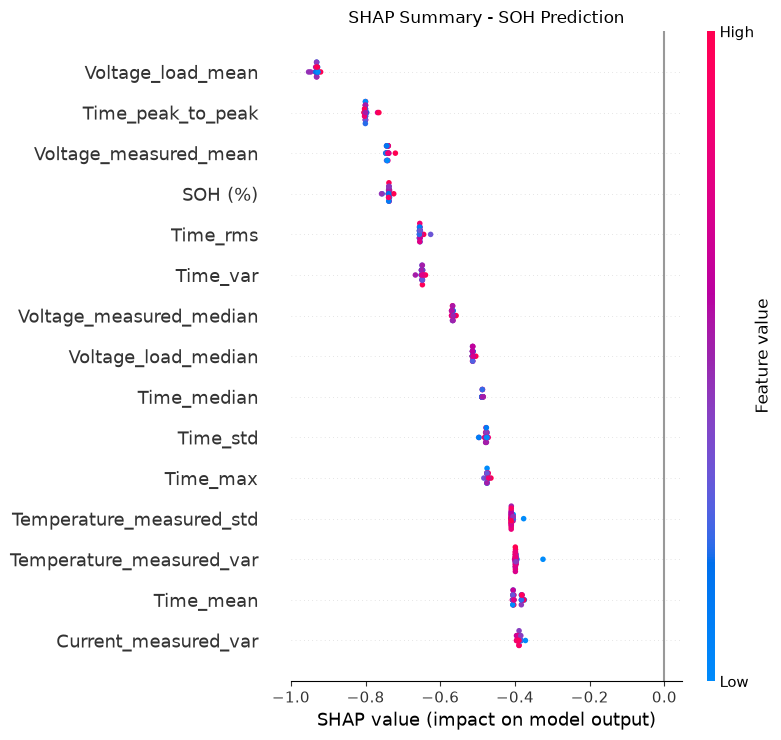

In [6]:
plot_shap_summary(shap_values, X_test, max_display=15, title="SHAP Summary - SOH Prediction")


### Observation
Look at the top 2-3 features: are high values (red/warm-colored points) associated with higher or lower predicted SOH? This should match physical intuition -- e.g. a higher `Voltage_measured_mean` should generally push predicted SOH up (a healthier battery discharges at a higher average voltage).


## 6. Dependence Plot — Top Feature

Shows how the single most important feature's effect on the prediction changes across its range, and which second feature it interacts with most.


Top feature by mean |SHAP value|: Voltage_load_mean


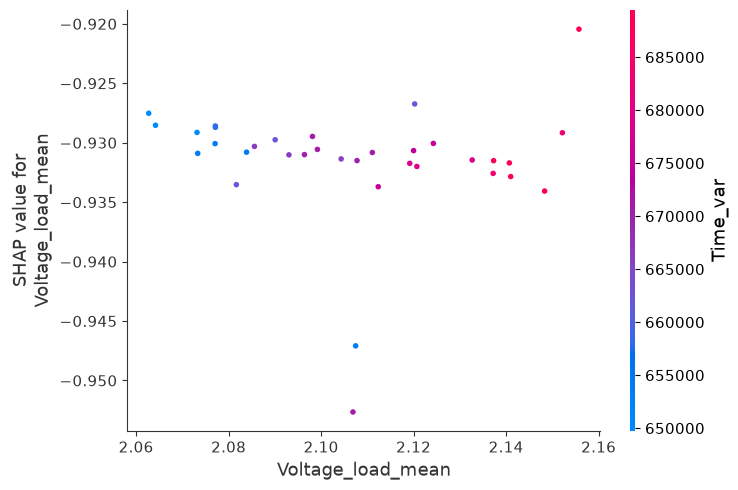

In [7]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = X_test.columns[top_feature_idx]

print(f"Top feature by mean |SHAP value|: {top_feature_name}")
plot_shap_dependence(top_feature_name, shap_values, X_test)


### Observation
This plot should show a clear trend (not random scatter) -- e.g. a roughly monotonic relationship between the feature's value and its SHAP contribution. Color banding (if present) shows the interaction effect with a second feature, worth a sentence of interpretation in your report.


## 7. Local Explanation — One Specific Prediction

A case-study figure: why did the model predict what it predicted for one particular test cycle (the last one available, i.e. the most degraded battery state we have data for).


In [8]:
row_idx = len(X_test) - 1
actual_val = y_test.iloc[row_idx]
predicted_val = ahrf_soh.predict(X_test.iloc[[row_idx]])[0]

print(f"Test row: cycle_index = {df.iloc[split + row_idx]['cycle_index']}")
print(f"Actual SOH: {actual_val:.2f}%   Predicted SOH: {predicted_val:.2f}%")

top_contributors = pd.Series(shap_values[row_idx], index=X_test.columns).sort_values(key=abs, ascending=False).head(8)
top_contributors


Test row: cycle_index = 168
Actual SOH: 66.25%   Predicted SOH: 68.77%


Voltage_load_mean         -0.926738
Time_peak_to_peak         -0.801366
Voltage_measured_mean     -0.737606
SOH (%)                   -0.736923
Time_var                  -0.651157
Time_rms                  -0.625882
Voltage_measured_median   -0.567357
Voltage_load_median       -0.512431
dtype: float64

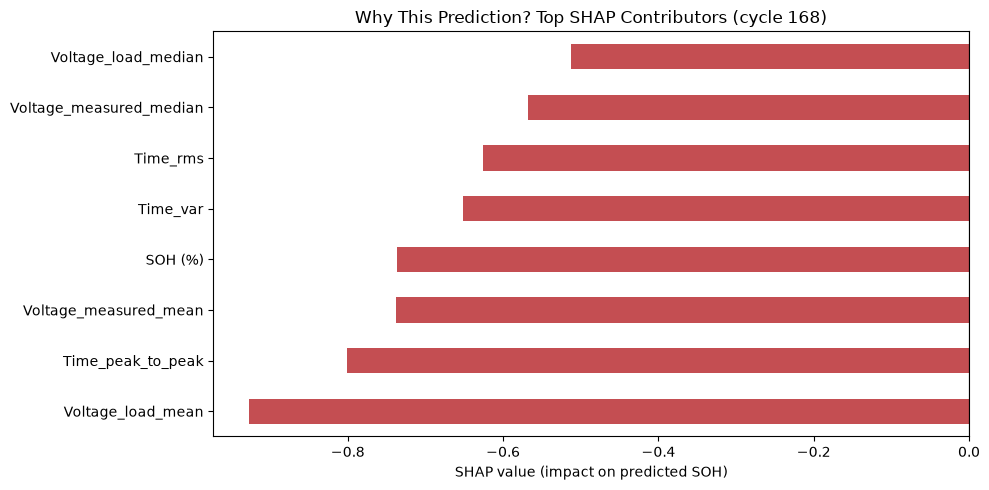

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in top_contributors.values]
top_contributors.sort_values().plot(kind="barh", ax=ax, color=colors)
ax.set_title(f"Why This Prediction? Top SHAP Contributors (cycle {df.iloc[split + row_idx]['cycle_index']})")
ax.set_xlabel("SHAP value (impact on predicted SOH)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


### Observation
Blue bars pushed the prediction UP, red bars pushed it DOWN. This is exactly the kind of figure to walk through live in a viva: "the model predicted SOH=X% for this cycle mainly because of feature Y, which makes physical sense because...".


## 8. Save Figures for the Report


In [10]:
FIGURES.mkdir(parents=True, exist_ok=True)

import shap
fig = plt.figure()
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.tight_layout()
plt.savefig(FIGURES / "shap_summary_soh.png", dpi=150, bbox_inches="tight")
plt.close()

print("Saved SHAP summary figure to", FIGURES / "shap_summary_soh.png")


Saved SHAP summary figure to C:\BE PROJECT\SBMS_PROJECT\reports\figures\shap_summary_soh.png


## Results Summary

| Item | Location |
|---|---|
| Global feature importance | Section 4 |
| Feature effect direction | Section 5 |
| Top feature interaction | Section 6 |
| Local (single-prediction) explanation | Section 7 |

## Conclusion
SHAP confirmed that the AHRF model's predictions are driven by physically sensible features (voltage- and duration-related statistics), both globally and for individual predictions. This directly addresses the reference paper's weak/absent explainability, using exact (not approximated) Shapley values via TreeSHAP.

## Next Steps
Notebook 08 will apply a simple rule-based decision engine to the model's predictions (maintenance recommendations) and compile the final results summary for the report.
